# A sampled closed shell: prove the wall before naming the cavity

This second DFND laboratory case contains 72 fictitious carbon-like atomic balls
near a sphere of radius 6 Å, with small fixed-seed coordinate jitter. A generator
called `hollow_sphere` does not by itself prove that its gaps seal a cavity.
We establish an independent coverage certificate for the 1.4 Å probe, inspect
the native description and compare several original providers.

Downloads: {download}`quantity-aware input <artifacts/closed_shell_v1/input.json>`,
{download}`canonical dummy PDB <artifacts/closed_shell_v1/input.pdb>`,
{download}`ATOM comparison PDB <artifacts/closed_shell_v1/input_atom.pdb>` and
{download}`recorded observations <artifacts/closed_shell_v1/report.json>`.
Use the environment and execution instructions in the [laboratory index](index.md).
This is a geometric control, not a protein or a biological site benchmark.

In [1]:
import hashlib
import html
import json
import shutil
from importlib.metadata import version
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from pyunitwizard import QuantityRecord
from scipy.spatial import ConvexHull

import topomt as tmt
from topomt import pyunitwizard as puw
from topomt.dfnd import DelaunayFlowNetwork

ARTIFACT_DIR = Path('artifacts/closed_shell_v1')
RUN_PROVIDERS = True
fixture_bytes = (ARTIFACT_DIR / 'input.json').read_bytes()
fixture = json.loads(fixture_bytes)


def quantity(field):
    return QuantityRecord.from_dict(fixture[field]).to_quantity(field=field, unit='angstroms')


def values(field):
    return np.asarray(puw.get_value(quantity(field), to_unit='angstroms'))


def qrecord(value, unit, field):
    return QuantityRecord.from_quantity(puw.quantity(value, unit), field=field).to_dict()


coords = values('coordinates')
radii = values('atom_radii')
probe_values = values('probe_sweep')
certified_probe = fixture['reference']['certified_probe_angstroms']
assert coords.shape == (72, 3) and radii.shape == (72,)
assert np.all(radii == 1.7)
assert hashlib.sha256((ARTIFACT_DIR / 'input_atom.pdb').read_bytes()).hexdigest() == fixture['provider_input']['sha256']

## Independent closure certificate

Construct the convex hull of the atom centers. For each triangular boundary
face, calculate the circumradius $R_f=abc/(4A)$ from its three edge lengths and
area. This is independent of DFND's gate solver.

For any point $p$ inside a triangle with barycentric weights $\lambda_i$, circle
center $c$ and vertices $v_i$, the identity

$$\sum_i\lambda_i\lVert p-v_i\rVert^2=R_f^2-\lVert p-c\rVert^2\le R_f^2$$

implies that at least one vertex is within $R_f$ of $p$. If every vertex ball,
expanded by the probe, has radius greater than every face's $R_f$, the **entire
hull boundary is covered**. A probe center cannot escape across this boundary.
We also verify that the origin is strictly inside the hull and farther from
every atom than its expanded radius. Together these facts establish **at least
one bounded free probe-center region containing the origin**.

This sufficient certificate does not prove that there is exactly one geometric
cavity. Failure of the coverage inequality is inconclusive: it does not prove
an opening. The 0.1 Å minimum positive margin was frozen before native evaluation.

In [2]:
hull = ConvexHull(coords)
triangles = coords[hull.simplices]
a = np.linalg.norm(triangles[:, 0] - triangles[:, 1], axis=1)
b = np.linalg.norm(triangles[:, 1] - triangles[:, 2], axis=1)
c = np.linalg.norm(triangles[:, 2] - triangles[:, 0], axis=1)
areas = np.linalg.norm(np.cross(triangles[:, 1] - triangles[:, 0],
                                triangles[:, 2] - triangles[:, 0]), axis=1) / 2
face_cover_radii = a * b * c / (4 * areas)
coverage_margin = float(radii.min() + certified_probe - face_cover_radii.max())
center_clearance = float(np.min(np.linalg.norm(coords, axis=1) - radii))
hull_inradius = float(-hull.equations[:, 3].max())
assert coverage_margin > fixture['reference']['minimum_margin_angstroms']
assert hull_inradius > 0 and center_clearance > certified_probe

# Geometric bare-solvent bounds: a guaranteed empty ball inside the hull,
# and the finite hull volume. Neither is an exact volume of this sampled shell.
guaranteed_empty_radius = min(center_clearance, hull_inradius)
empty_volume_lower = 4 * np.pi * guaranteed_empty_radius**3 / 3
empty_volume_upper = float(hull.volume)
display(Markdown(
    f'**Certified wall margin:** {coverage_margin:.6f} Å. '
    f'**Origin clearance:** {center_clearance:.6f} Å.\n\n'
    f'Total bare free-space volume restricted to the finite hull is bounded by '
    f'**{empty_volume_lower:.3f}–{empty_volume_upper:.3f} Å³**. '
    'These are geometric bounds, not a precision guarantee for DFND quadrature.'
))

**Certified wall margin:** 1.070469 Å. **Origin clearance:** 4.168062 Å.

Total bare free-space volume restricted to the finite hull is bounded by **303.313–839.875 Å³**. These are geometric bounds, not a precision guarantee for DFND quadrature.

## Inspect the input

Points mark atomic centers and translucent triangles show the boundary used by
the certificate. The guaranteed empty ball is drawn in blue; it is inside both
the hull and the free space of the unexpanded atomic balls. It is not the exact
cavity surface.

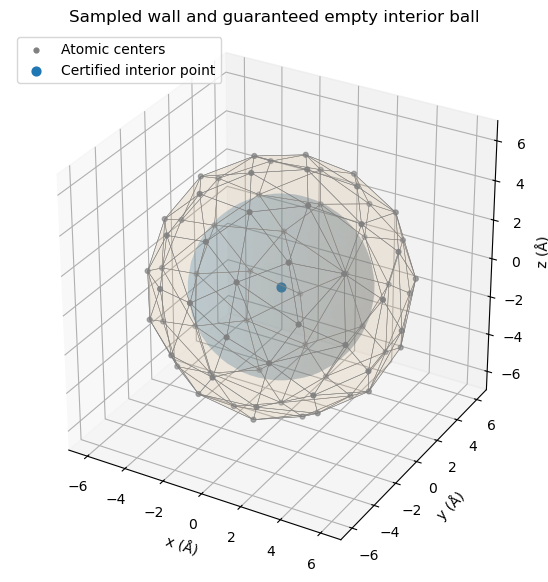

In [3]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection='3d')
ax.add_collection3d(Poly3DCollection(triangles, facecolor='tan', edgecolor='grey',
                                    alpha=0.12, linewidth=0.35))
ax.scatter(*coords.T, s=12, color='grey', label='Atomic centers')
u, v = np.linspace(0, 2 * np.pi, 40), np.linspace(0, np.pi, 20)
surface = guaranteed_empty_radius * np.array([
    np.outer(np.cos(u), np.sin(v)), np.outer(np.sin(u), np.sin(v)),
    np.outer(np.ones_like(u), np.cos(v)),
])
ax.plot_surface(*surface, color='tab:blue', alpha=0.16, linewidth=0)
ax.scatter(0, 0, 0, color='tab:blue', s=40, label='Certified interior point')
ax.set(xlim=(-7, 7), ylim=(-7, 7), zlim=(-7, 7),
       xlabel='x (Å)', ylabel='y (Å)', zlabel='z (Å)', title='Sampled wall and guaranteed empty interior ball')
ax.set_box_aspect((1, 1, 1))
ax.legend(loc='upper left')
fig.subplots_adjust(left=0.02, right=0.88, bottom=0.02, top=0.9)
plt.show()

## Native central component

Find the finite cell containing the origin by barycentric containment and inspect
the raw wet component that includes it. This ties the graph observation to the
independently certified spatial region, rather than choosing the largest output
after seeing it. We retain `min_size=0` and do not prescribe the global cavity
count or suppress smaller components.

In [4]:
network = DelaunayFlowNetwork.from_coordinates_and_radii(
    quantity('coordinates'), quantity('atom_radii'), epsilon=quantity('epsilon')
)
vertices = network.atom_coords[network.tetra_atoms]
matrices = np.swapaxes(vertices[:, 1:] - vertices[:, :1], 1, 2)
barycentric = np.linalg.solve(matrices, -vertices[:, 0, :, None])[:, :, 0]
containing = set(map(int, np.flatnonzero(
    np.all(barycentric >= -1e-8, axis=1) & (barycentric.sum(axis=1) <= 1 + 1e-8)
)))
assert containing


def observe(probe):
    raw = network.get_topography(probe_radius=puw.quantity(float(probe), 'angstroms'),
                                **fixture['query'])['raw']
    central = [component for component in raw['wet_components']
               if containing & set(component['tetrahedron_ids'])]
    assert len(central) <= 1
    component = central[0] if central else None
    return {
        'probe_angstroms': float(probe),
        'wet_component_count': len(raw['wet_components']),
        'resident_node_count': sum(item['residence_state'] == 'resident' for item in raw['tetrahedra']),
        'central_family': component['family'] if component else 'no_wet_component',
        'central_resident_nodes': int(component['n_resident_nodes']) if component else 0,
        'central_external_links': int(component['n_external_links']) if component else None,
        'central_solvent_volume_estimate_angstroms3': float(component['volume_solvent_estimate'] * 1000) if component else None,
        'boundary_coverage_margin_angstroms': float(radii.min() + probe - face_cover_radii.max()),
    }


certified = observe(certified_probe)
assert certified['central_family'] == fixture['reference']['expected_central_component']
assert certified['central_external_links'] == fixture['reference']['expected_central_external_links']
anchors = [observe(probe) for probe in values('anchor_probes')]
sweep = [observe(probe) for probe in probe_values]
display(Markdown(
    f"At {certified_probe:.1f} Å: central family **{certified['central_family']}**, "
    f"**{certified['central_resident_nodes']}** resident nodes, "
    f"**{certified['central_external_links']}** external links.\n\n"
    f"DFND reports a solvent-volume estimate of **{certified['central_solvent_volume_estimate_angstroms3']:.3f} Å³**. "
    'The finite-cell quadrature and region partition have not been independently certified to a numerical tolerance.'
))

At 1.4 Å: central family **void**, **33** resident nodes, **0** external links.

DFND reports a solvent-volume estimate of **501.681 Å³**. The finite-cell quadrature and region partition have not been independently certified to a numerical tolerance.

The volume bounds refer to total **bare free space restricted to the finite
hull**. They do not claim that the unexpanded atomic balls seal a physical
cavity. The closure certificate refers to **probe centers**, using expanded
atomic balls. DFND's reported solvent estimate is not automatically the volume
available to probe centers. No continuum-sphere volume is used as an exact
target, and the graph skeleton does not certify a continuous collision-free path.

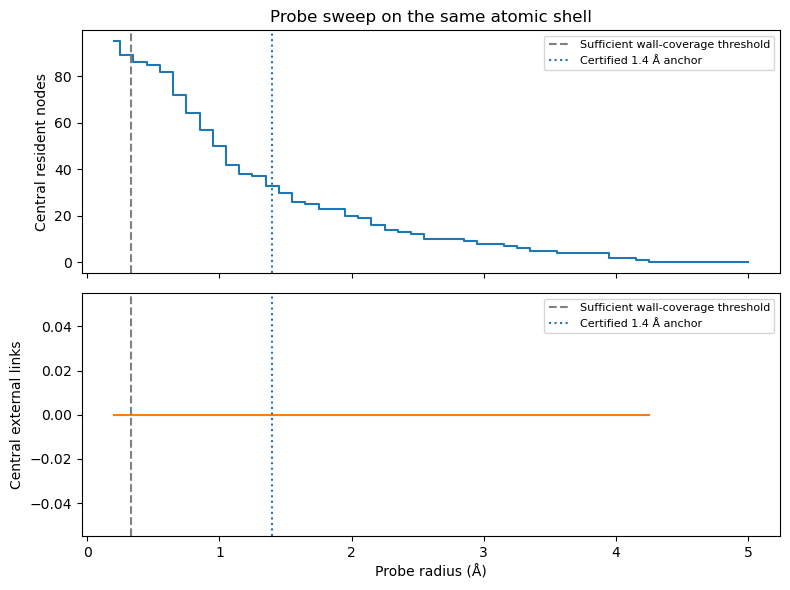

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
axes[0].step(probe_values, [item['central_resident_nodes'] for item in sweep], where='mid')
axes[0].set(ylabel='Central resident nodes', title='Probe sweep on the same atomic shell')
axes[1].step(probe_values, [item['central_external_links'] if item['central_external_links'] is not None else np.nan
                          for item in sweep], where='mid', color='tab:orange')
axes[1].set(xlabel='Probe radius (Å)', ylabel='Central external links')
certificate_threshold = face_cover_radii.max() - radii.min()
for ax in axes:
    ax.axvline(certificate_threshold, linestyle='--', color='grey', label='Sufficient wall-coverage threshold')
    ax.axvline(certified_probe, linestyle=':', color='tab:blue', label='Certified 1.4 Å anchor')
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## Compare several original providers on identical PDB coordinates

The comparison export changes only `HETATM` to `ATOM`, retaining the fictitious
carbon labels, DUM residue and coordinate columns. This makes the role of PDB
record filtering explicit without claiming a protein topology or changing the
geometry to obtain a match. All four original providers receive these same
rounded coordinates. Their radius models, filtering and region definitions
remain their own. Detection thresholds are not tuned for agreement.

Each provider runs in a separate process through TopoMT's original-provider API.
This isolates upstream compatibility shims from the native experiment. Completed
runs retain checksum-verified original bundles and explicitly defined pocket
geometries; failure and unavailability are separate from a completed zero-pocket
run. Local reruns write only a new ignored `runs/` folder, never the frozen input
or the published report. AlphaSpace2 uses the adapter's documented geometry-only
route without a binder or Vina receptor typing.


In [6]:
"""Notebook cell: original providers in isolated processes with recoverable runs."""

import subprocess
import sys
import uuid
from importlib.util import find_spec

RUN_DIRECTORY = Path('runs') / uuid.uuid4().hex
RUN_DIRECTORY.mkdir(parents=True)

# The subprocess isolates upstream compatibility shims and keeps failures local
# to the optional comparison. Native reference assertions run independently.
PROVIDER_WORKER = r'''
import hashlib
import json
import re
import sys
from pathlib import Path
from pyunitwizard import QuantityRecord
import topomt as tmt
from topomt import pyunitwizard as puw

method, pdb_name, result_name, bundle_name = sys.argv[1:]
result = {'method': method, 'status': 'execution_failed', 'pocket_count': None}
try:
    output = tmt.get_provider_output(pdb_name, method=method,
                                    backend='cli' if method == 'fpocket' else 'library')
except Exception as error:
    reason = str(error)
    if isinstance(error, __import__('subprocess').CalledProcessError):
        reason = f'Original engine subprocess exited with code {error.returncode}:\n' + (error.stderr or '')[-1500:]
    reason = re.sub(r"'[^'\n]*\.pdb'", "'<submitted PDB>'", reason)
    reason = re.sub(r'/tmp/[^\s\n\'\"]+', '<temporary path>', reason)
    reason = re.sub(r'/home/[^\s\n\'\"]+', '<installed source>', reason)
    result.update(error_type=type(error).__name__, reason=reason[:1600])
else:
    output.run.save(bundle_name)
    pockets = []
    for pocket in output.pockets:
        geometries = {}
        for name, geometry in pocket.geometries.items():
            geometries[name] = {
                'definition': geometry.definition,
                'coordinates': QuantityRecord.from_quantity(
                    geometry.coordinates, field='coordinates').to_dict(),
                'radii': None if geometry.radii is None else QuantityRecord.from_quantity(
                    geometry.radii, field='radii').to_dict(),
            }
        measurements = {
            name: {'quantity': QuantityRecord.from_quantity(item.value, field=name).to_dict()
                               if puw.is_quantity(item.value) else None,
                   'original_value': item.original_value,
                   'definition': item.definition, 'source_field': item.source_field,
                   'original_unit': item.original_unit, 'status': item.status}
            for name, item in pocket.measurements.items()
        }
        pockets.append({'source_id': pocket.source_id, 'geometries': geometries,
                        'measurements': measurements})
    result.update(status='completed', pocket_count=len(pockets), pockets=pockets,
                  run_id=output.run.run_id, execution_metadata=output.run.metadata,
                  original_bundle={'file': Path(bundle_name).name,
                                   'sha256': hashlib.sha256(Path(bundle_name).read_bytes()).hexdigest()})
Path(result_name).write_text(json.dumps(result, indent=2, allow_nan=False))
'''

comparison_pdb = ARTIFACT_DIR / 'input_atom.pdb'
canonical_lines = (ARTIFACT_DIR / 'input.pdb').read_text().splitlines()
atom_lines = comparison_pdb.read_text().splitlines()
assert len(atom_lines) == len(canonical_lines)
assert all(a[6:] == b[6:] for a, b in zip(atom_lines, canonical_lines))
comparisons = []
for method in ['fpocket', 'pocketeer', 'alphaspace2', 'pycasta']:
    executable = shutil.which('fpocket') if method == 'fpocket' else None
    available = executable is not None if method == 'fpocket' else find_spec(method) is not None
    entry = {
        'method': method, 'backend': 'cli' if method == 'fpocket' else 'library',
        'settings': 'Provider defaults; geometry-only AlphaSpace2 route, no binder or Vina typing',
        'input_sha256': hashlib.sha256(comparison_pdb.read_bytes()).hexdigest(),
        'input_encoding': 'Synthetic ATOM carbon rows with DUM residue; no inferred biological topology',
        'status': 'not_requested', 'pocket_count': None,
    }
    if RUN_PROVIDERS and not available:
        entry.update(status='unavailable', reason='Original provider is not installed')
    elif RUN_PROVIDERS:
        if executable:
            entry['executable_sha256'] = hashlib.sha256(Path(executable).read_bytes()).hexdigest()
        else:
            entry['software_version'] = version(method)
        result_path = RUN_DIRECTORY / f'{method}.json'
        bundle_path = RUN_DIRECTORY / f'{method}_original.zip'
        try:
            execution = subprocess.run(
                [sys.executable, '-c', PROVIDER_WORKER, method, str(comparison_pdb.resolve()),
                 str(result_path.resolve()), str(bundle_path.resolve())],
                capture_output=True, text=True, timeout=180,
            )
        except subprocess.TimeoutExpired:
            entry.update(status='execution_failed', error_type='TimeoutExpired',
                         reason='Provider comparison exceeded 180 seconds')
        else:
            if execution.returncode != 0 or not result_path.exists():
                entry.update(status='execution_failed', error_type='WorkerProcessError',
                             reason=f'Comparison worker failed (exit {execution.returncode}); inspect local logs')
            else:
                entry.update(json.loads(result_path.read_text()))
            (RUN_DIRECTORY / f'{method}_stdout.txt').write_text(execution.stdout)
            (RUN_DIRECTORY / f'{method}_stderr.txt').write_text(execution.stderr)
    comparisons.append(entry)

table = '<table><thead><tr><th>Original provider</th><th>Outcome</th><th>Reported pockets</th></tr></thead><tbody>'
table += ''.join(
    f"<tr><td>{item['method']}</td><td>{item['status']}</td><td>"
    f"{item['pocket_count'] if item['pocket_count'] is not None else '—'}</td></tr>"
    for item in comparisons
)
display({'text/html': table + '</tbody></table>'}, raw=True)
for item in comparisons:
    if item['status'] == 'execution_failed':
        display(Markdown(f"**{item['method']}:** {item.get('reason', 'Execution failed')}"))


Original provider,Outcome,Reported pockets
fpocket,execution_failed,—
pocketeer,completed,1
alphaspace2,completed,1
pycasta,execution_failed,—


**fpocket:** fpocket failed with code 1:
! malloc failed in my_bloc_malloc. Programm will exit, as demanded.


**pycasta:** Original engine subprocess exited with code 1:
WARNING:root:PyMOL not found. SASA will not be computed using PyMOL.
WARNING:root:pymol2 not found.
WARNING:root:Alpha shape filtered out all tetrahedra. No pockets detected.
Traceback (most recent call last):
  File "<string>", line 10, in <module>
    result = run_analysis.process_pdb(sys.argv[2])
  File "<temporary path>", line 490, in process_pdb
    ranked_pockets = pocket_info.get("ranked_pockets", [])
                     ^^^^^^^^^^^^^^^
AttributeError: 'tuple' object has no attribute 'get'


## Compare the reported representations

The peer markers below are provider-defined alpha-sphere centers, when present.
They are not exact pocket boundaries. DFND markers are centroids of the resident
tetrahedra in the certified central component, rather than alpha spheres. The
different point counts therefore have different meanings. A missing or failed
provider has no fabricated geometry in its panel.

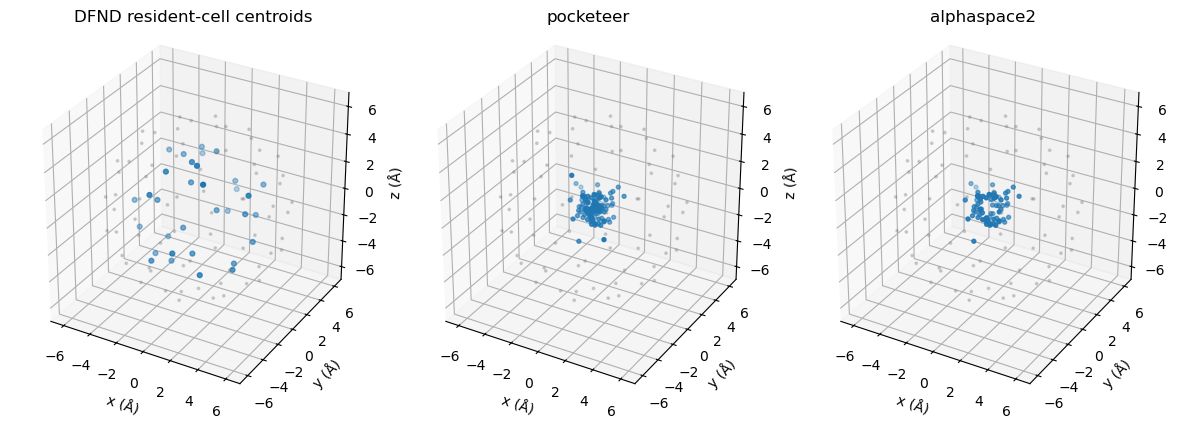

In [7]:
fig = plt.figure(figsize=(12, 4))
panels = [('DFND resident-cell centroids', None)] + [
    (item['method'], item) for item in comparisons if item['status'] == 'completed'
]
raw = network.get_topography(probe_radius=puw.quantity(certified_probe, 'angstroms'),
                            **fixture['query'])['raw']
central = next(item for item in raw['wet_components'] if containing & set(item['tetrahedron_ids']))
for index, (name, provider) in enumerate(panels):
    ax = fig.add_subplot(1, len(panels), index + 1, projection='3d')
    ax.scatter(*coords.T, s=3, color='grey', alpha=0.3)
    if provider is None:
        points = coords[network.tetra_atoms[central['resident_tetrahedron_ids']]].mean(axis=1)
        ax.scatter(*points.T, s=12, color='tab:blue')
    else:
        for pocket in provider['pockets']:
            geometry = pocket['geometries'].get('alpha_spheres')
            if geometry:
                points = puw.get_value(QuantityRecord.from_dict(geometry['coordinates']).to_quantity(
                    field='coordinates', unit='angstroms'), to_unit='angstroms')
                ax.scatter(*points.T, s=8)
    ax.set(xlim=(-7, 7), ylim=(-7, 7), zlim=(-7, 7), title=name,
           xlabel='x (Å)', ylabel='y (Å)', zlabel='z (Å)')
    ax.set_box_aspect((1, 1, 1))
fig.tight_layout()
plt.show()

## Recorded CASTp server attempts

These observations use TopoMT's existing original-server adapters. Re-executing
this notebook reads the recorded attempts and **does not upload another job**.
CASTp 3.0 rejected the upload with `Something wrong with upload! 7`, before a job
identifier was returned. CASTpFold returned a job identifier for the corrected
HETATM export, but no result ZIP was available during the recorded checks.
`submitted_pending` means completion was not observed; it is neither a completed
zero-pocket result nor proof that the calculation failed. A later observation
should retrieve the same job before considering a new submission.

The CASTpFold export corrects the alignment of the one-letter carbon atom name;
it preserves coordinates, element fields and fictitious DUM residue labels.
Acceptance of the upload does not establish that the server retains every DUM
atom or assigns our reference radius of 1.7 Å. Neither web form accepts our
explicit per-atom radius array. The CASTp 3.0 attempt used the earlier ATOM export;
the two attempts therefore do not isolate the effect of the server version.

The [CASTpFold form](https://cfold.bme.uic.edu/castpfold/compute) allows PDB/mmCIF,
one model, files below 2,000,000 bytes and probes from 0 to 10 Å. Its documented
calculation time is minutes to hours. The current TopoMT client accepts probes
only through 5 Å; our 1.4 Å query is inside both ranges. CASTpFold reports SA
quantities, whose definitions must be retained in any subsequent comparison.


In [8]:
server_observations = []
for method in ['castp3', 'castpfold']:
    observation = json.loads((ARTIFACT_DIR / f'{method}_observation.json').read_text())
    submitted = ARTIFACT_DIR / observation['input_file']
    assert hashlib.sha256(submitted.read_bytes()).hexdigest() == observation['input_sha256']
    assert observation['evidence_mode'] == 'recorded_original_server_attempt'
    server_observations.append(observation)
comparisons.extend(server_observations)
table = '<table><thead><tr><th>Server</th><th>Recorded outcome</th><th>Job identifier</th></tr></thead><tbody>'
table += ''.join(f"<tr><td>{item['server']}</td><td>{item['status']}</td>"
                 f"<td>{item.get('jobid', '—')}</td></tr>" for item in server_observations)
display({'text/html': table + '</tbody></table>'}, raw=True)


Server,Recorded outcome,Job identifier
castp3,execution_failed,—
castpfold,submitted_pending,j_6abe78a074161


## Reproducible observations and limitations

The report links the quantity-aware input and original PDB submission by checksum,
records the independent certificate, probe observations, exact provider outcomes
and original-run bundle checksums. Imported version labels and a digest of the
actual installed TopoMT source supplement editable-package metadata.

This case validates correspondence to an independently enclosed central region,
not complete physical topology or solvent-volume accuracy. Each provider's
definitions, parameters and input-domain failures remain visible. Original run
bundles from completed executions accompany the reviewed report; reruns produce
new local evidence without replacing the published artifacts.

In [9]:
# Editable distribution metadata can lag the current checkout.
# Hash actual installed source bytes as well as reporting version labels.
source_root = Path(tmt.__file__).parent
source_files = sorted(source_root.rglob('*.py'))
source_digest = hashlib.sha256()
for source_file in source_files:
    relative_name = source_file.relative_to(source_root).as_posix()
    content = source_file.read_bytes()
    source_digest.update(relative_name.encode() + b'\0')
    source_digest.update(str(len(content)).encode() + b'\0' + content)

report = {
    'schema': 'topomt.dfnd.reference-observations/1',
    'case_id': fixture['case_id'], 'case_version': fixture['case_version'],
    'input_sha256': hashlib.sha256(fixture_bytes).hexdigest(),
    'software': {name: version(name) for name in
                 ['topomt', 'molsysmt', 'pyunitwizard', 'numpy', 'scipy', 'depdigest', 'matplotlib']},
    'topomt_source': {'scope': 'Installed topomt/**/*.py, sorted relative paths and length-delimited bytes',
                      'file_count': len(source_files), 'sha256': source_digest.hexdigest()},
    'query': fixture['query'], 'reference': fixture['reference'], 'reference_checks': 'passed',
    'certificate': {
        'coverage_margin': qrecord(coverage_margin, 'angstroms', 'coverage_margin'),
        'center_clearance': qrecord(center_clearance, 'angstroms', 'center_clearance'),
        'finite_hull_volume': qrecord(hull.volume, 'angstroms**3', 'finite_hull_volume'),
        'bare_free_volume_lower_bound': qrecord(empty_volume_lower, 'angstroms**3', 'bare_free_volume_lower_bound'),
    },
    'certified_observation': certified, 'anchors': anchors, 'sweep': sweep,
    'provider_comparisons': comparisons,
    'limits': ['No exact physical cavity-count claim', 'No solvent-volume precision guarantee',
               'No validated continuous probe path', 'No peer-agreement acceptance gate',
               'Synthetic ATOM encoding is not a biological topology'],
}
report_text = json.dumps(report, indent=2, allow_nan=False)
display({'text/plain': report_text,
         'text/html': '<details><summary>Complete structured observations</summary><pre>'
                      + html.escape(report_text) + '</pre></details>'}, raw=True)

{
  "schema": "topomt.dfnd.reference-observations/1",
  "case_id": "closed_shell",
  "case_version": 1,
  "input_sha256": "ef19995751b2df58c8b1556011f74fa4774e924b9cd499138b8741988b650157",
  "software": {
    "topomt": "0.3.0+2.g5dde63c.dirty",
    "molsysmt": "0.21.0+606.ga03eb4bf6",
    "pyunitwizard": "0.25.0+7.g00d756c",
    "numpy": "2.4.6",
    "scipy": "1.18.0",
    "depdigest": "0.12.0",
    "matplotlib": "3.10.9"
  },
  "topomt_source": {
    "scope": "Installed topomt/**/*.py, sorted relative paths and length-delimited bytes",
    "file_count": 229,
    "sha256": "f1403d55fd5e402044eae7fb61ee5448663332dcc67f9d071bb5b5d46369cf69"
  },
  "query": {
    "min_size": 0
  },
  "reference": {
    "method": "Independent convex-hull triangle coverage by probe-expanded atomic balls plus a free, strictly interior center.",
    "certified_probe_angstroms": 1.4,
    "minimum_margin_angstroms": 0.1,
    "expected_central_component": "void",
    "expected_central_external_links": 0,
    "scope": "At least one enclosed free probe-center region containing the origin. No exact cavity count, continuous graph-path or solvent-volume accuracy claim."
  },
  "reference_checks": "passed",
  "certificate": {
    "coverage_margin": {
      "manifest": {
        "format": "qrec/0.3",
        "field": "coverage_margin",
        "unit": "angstrom",
        "si": {
          "factor": 1e-10,
          "offset": 0.0,
          "exponents": {
            "m": 1
          }
        },
        "dtype": "float64",
        "shape": [],
        "blocks": [
          1
        ]
      },
      "values": 1.0704692768733084,
      "block_digests": [
        "blake2b-128:1f9ef37414a82525af7606f1b0c05b1a"
      ],
      "digest": "blake2b-128:343e01145ba5c9a93f5059e978038019"
    },
    "center_clearance": {
      "manifest": {
        "format": "qrec/0.3",
        "field": "center_clearance",
        "unit": "angstrom",
        "si": {
          "factor": 1e-10,
          "offset": 0.0,
          "exponents": {
            "m": 1
          }
        },
        "dtype": "float64",
        "shape": [],
        "blocks": [
          1
        ]
      },
      "values": 4.168062463748159,
      "block_digests": [
        "blake2b-128:909e0bd75e2fb2ec71b756356408a610"
      ],
      "digest": "blake2b-128:8f490063bf426181b50e19b3edc00129"
    },
    "finite_hull_volume": {
      "manifest": {
        "format": "qrec/0.3",
        "field": "finite_hull_volume",
        "unit": "angstrom ** 3",
        "si": {
          "factor": 1e-30,
          "offset": 0.0,
          "exponents": {
            "m": 3
          }
        },
        "dtype": "float64",
        "shape": [],
        "blocks": [
          1
        ]
      },
      "values": 839.8750754136796,
      "block_digests": [
        "blake2b-128:23053b6943d1f327634496b1c2ef1f97"
      ],
      "digest": "blake2b-128:2751f0d0a3090182f8644e44b66800a8"
    },
    "bare_free_volume_lower_bound": {
      "manifest": {
        "format": "qrec/0.3",
        "field": "bare_free_volume_lower_bound",
        "unit": "angstrom ** 3",
        "si": {
          "factor": 1e-30,
          "offset": 0.0,
          "exponents": {
            "m": 3
          }
        },
        "dtype": "float64",
        "shape": [],
        "blocks": [
          1
        ]
      },
      "values": 303.31316839947783,
      "block_digests": [
        "blake2b-128:1fba9174257975be07c2b5bb10ebb15f"
      ],
      "digest": "blake2b-128:040a5c0c46e3f1b3e8f92e3c17301406"
    }
  },
  "certified_observation": {
    "probe_angstroms": 1.4,
    "wet_component_count": 1,
    "resident_node_count": 33,
    "central_family": "void",
    "central_resident_nodes": 33,
    "central_external_links": 0,
    "central_solvent_volume_estimate_angstroms3": 501.6805100647046,
    "boundary_coverage_margin_angstroms": 1.0704692768733084
  },
  "anchors": [
    {
      "probe_angstroms": 0.2,
      "wet_component_count": 1,
      "resident_node_count": 95

Reviewed original evidence: {download}`pocketeer original run <artifacts/closed_shell_v1/pocketeer_original.zip>`, {download}`alphaspace2 original run <artifacts/closed_shell_v1/alphaspace2_original.zip>`.

In the reviewed execution, Pocketeer and AlphaSpace2 each report one pocket,
but their volume fields have different definitions: Pocketeer reports
931.75 Å³ from its voxel estimate, AlphaSpace2 reports 91.02 Å³ as a sum of
alpha-space tetrahedron volumes, and DFND reports a 501.68 Å³ solvent estimate
for the central wet component. These are not three measurements of the same
certified physical region. The point representations below likewise describe
different objects. No agreement threshold is inferred from these numbers.

fpocket exits with its `my_bloc_malloc` error on this synthetic ATOM export;
this observation does not establish physical memory exhaustion. pyCASTA 1.0.8
filters out all tetrahedra and then raises `AttributeError` because an upstream
tuple is treated as a dictionary. Both are failed runs, not zero-pocket results.
These input-domain/error-path findings remain outside native validation.


## Review before continuing

The wall is certified at 1.4 Å and DFND identifies a central sealed resident
region. This is a stronger reference than a generator's shape name. The native
resident-cell representation and the peers' alpha-site representations need not
coincide. Original-provider execution failures are a separate finding.

Together with the tetrahedron, this completes the two-case study tranche.
We pause here for review before introducing an opening, a tube or a neck, or
changing the native algorithm. Volume precision and general biological validation
remain open work.

Recorded server evidence: {download}`CASTp 3.0 observation <artifacts/closed_shell_v1/castp3_observation.json>`, {download}`CASTpFold observation <artifacts/closed_shell_v1/castpfold_observation.json>`, {download}`CASTpFold aligned HETATM input <artifacts/closed_shell_v1/input_castp.pdb>`.